   rank power_unit    rating  wins  losses  games
0     1    Ferrari  0.627891    29      15     56
1     2   Mercedes  0.586087    29      21     58
2     3      Honda  0.544420    24      23     58
3     4    Renault  0.241602     4      27     32
PU list: ['Ferrari', 'Honda', 'Mercedes', 'Renault']


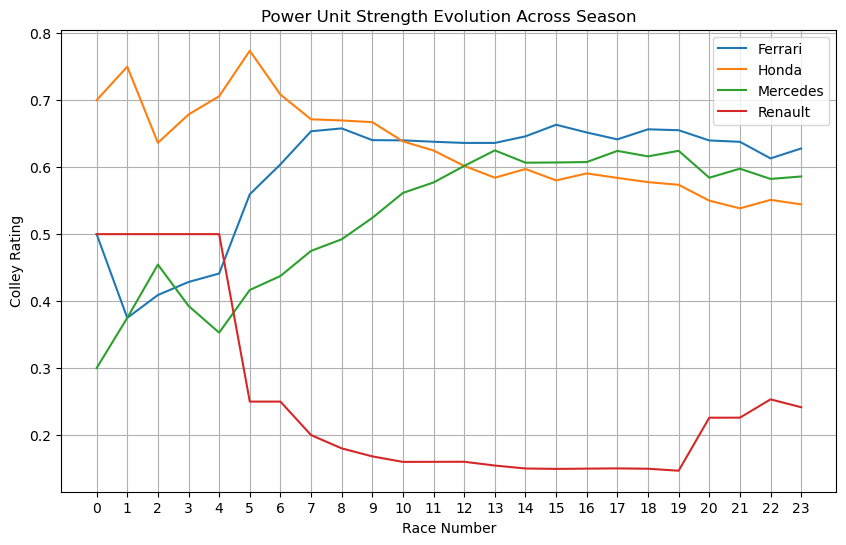

Spearman correlation between Colley rating and summed PU points: 0.7999999999999999 p= 0.20000000000000007
Sample raceId 1121
Race name: Bahrain Grand Prix
   position   constructor power_unit
0       1.0      Red Bull      Honda
1       2.0      Red Bull      Honda
2       3.0       Ferrari    Ferrari
3       4.0       Ferrari    Ferrari
4       5.0      Mercedes   Mercedes
5       6.0       McLaren   Mercedes
6       7.0      Mercedes   Mercedes
7       8.0       McLaren   Mercedes
8       9.0  Aston Martin   Mercedes
9      10.0  Aston Martin   Mercedes


In [5]:
# Loading all Neccessary Libraries
import pandas as pd
import numpy as np
from itertools import combinations
from numpy.linalg import solve
from scipy.stats import spearmanr 
import matplotlib.pyplot as plt

# COnfiguring
SEASON = 2024   
RESULTS_PATH = "results.csv"        
RACES_PATH   = "races.csv"
CONSTRUCTORS_PATH = "constructors.csv"

# Mapping all the Power Units to the Constructors 
PU_MAPPING = {
    "Red Bull": "Honda",
#     "AlphaTauri": "Honda",
    "RB F1 Team": "Honda",

    "Mercedes": "Mercedes",
    "McLaren": "Mercedes",
    "Aston Martin": "Mercedes",
    "Williams": "Mercedes",

    "Ferrari": "Ferrari",
    "Haas F1 Team": "Ferrari",
    "Sauber": "Ferrari", 
#     "Alfa Romeo": "Ferrari",

    "Alpine F1 Team": "Renault"

}

# Loading all necessary files
results = pd.read_csv(RESULTS_PATH)    
races   = pd.read_csv(RACES_PATH)
constructors = pd.read_csv(CONSTRUCTORS_PATH)

#Setting Race order for the Season
race_order = (
    races[races["year"] == SEASON]
    .sort_values("round")["raceId"]
    .tolist()
)

# normalizing all text columns (trim)
for col in ["constructor_name", "name", "position", "status"]:
    if col in results.columns:
        results[col] = results[col].astype(str).str.strip()

# Mapping COnstructor Id to each constructor 
if "constructorId" in results.columns and "constructorId" in constructors.columns:
    # constructors likely has ['constructorId', 'name']
    results = results.merge(constructors[["constructorId","name"]], how="left", left_on="constructorId", right_on="constructorId")
    results = results.rename(columns={"name":"constructor"})
results["constructor"] = results["constructor"].astype(str).str.strip()

# === 3) Filtering the Season, by excluding all the sprints
season_races = races[races["year"] == SEASON]
season_race_ids = season_races["raceId"].unique()

# If results contain session type, filter; else filter by raceId list
results = results[results["raceId"].isin(season_race_ids)]

# Some datasets include sprint_results table, making sure to exclude sprint session rows if present
if "session" in results.columns:
    results = results[results["session"].str.lower() == "race"]

# === 4) Filtering so we keep only P1-P10.
# Convert position to numeric.
results["position"] = pd.to_numeric(results["position"], errors="coerce")
top10 = results[(results["position"].notna()) & (results["position"] <= 10)].copy()

# Sanity - each race should have more than 10 rows (some races may have <10 if penalties or missing)
# print("unique races in top10:", top10["raceId"].nunique())

# === 5) MAP constructors to the power_unit according ot 
    # Use provided PU_MAPPING; ensure constructor names match keys exactly
top10["power_unit"] = top10["constructor"].map(PU_MAPPING)

# Check for unmapped constructors
unmapped = top10[top10["power_unit"].isna()]["constructor"].unique()
if len(unmapped) > 0:
    print("UNMAPPED constructors (fix PU_MAPPING):", unmapped)
    # Stop here so user fixes mapping
    raise SystemExit("Please update PU_MAPPING or constructors power-unit data.")

# === 6) Build per-race PU lists (only P1-P10) 
# For each race, building a DataFrame as raceId -> list of (position, pu)
race_groups = {}
for raceId, grp in top10.groupby("raceId"):
    # create sorted list by finishing position
    race_df = grp.sort_values("position")[["position","constructor","power_unit"]].copy()
    race_groups[raceId] = race_df.reset_index(drop=True)

# print("Sample race:", list(race_groups.keys())[:3])

# === 7) For each race compute PU-level as pairwise binary outcome 
pus = sorted(top10["power_unit"].unique())
P = len(pus)
pu_to_idx = {pu:i for i,pu in enumerate(pus)}

# Initializing season level matrices
N = np.zeros((P,P), dtype=int)   # number of races both PUs present in top 10
wins = np.zeros(P, dtype=int)
losses = np.zeros(P, dtype=int)

# Helping to compute pairwise wins for two PUs in a single race
def race_pair_result(race_df, puA, puB):
    # get positions of cars using puA and puB
    posA = race_df[race_df["power_unit"] == puA]["position"].values
    posB = race_df[race_df["power_unit"] == puB]["position"].values
    # if either is empty, they didn't participate in top10 therfore no comparison
    if len(posA) == 0 or len(posB) == 0:
        return None   # means no n_ij increment
    # count pairwise comparisons. every A vs every B
    a_beats_b = 0
    b_beats_a = 0
    for pa in posA:
        for pb in posB:
            if pa < pb:
                a_beats_b += 1
            elif pb < pa:
                b_beats_a += 1
            # equal shouldn't happen for unique positions
    if a_beats_b > b_beats_a:
        return 1   # A wins
    elif b_beats_a > a_beats_b:
        return -1  # B wins
    else:
        return 0   # draw

for raceId, race_df in race_groups.items():
    # for all PU pairs
    for puA, puB in combinations(pus, 2):
        res = race_pair_result(race_df, puA, puB)
        if res is None:
            continue  # at least one PU not present in top10 - skip
        i = pu_to_idx[puA]; j = pu_to_idx[puB]
        # increment n_ij
        N[i,j] += 1
        N[j,i] += 1
        if res == 1:
            wins[i] += 1
            losses[j] += 1
        elif res == -1:
            wins[j] += 1
            losses[i] += 1
        # draw -> no wins/losses increment, but N updated already

# === 8) Building the Colley matrix and solve 
games_played = N.sum(axis=1)   # t_i = sum_j n_ij (number of pairwise race comparisons participated)

C = np.zeros((P,P), dtype=float)
b = np.zeros(P, dtype=float)
for i in range(P):
    C[i,i] = 2 + games_played[i]
    b[i] = 1 + (wins[i] - losses[i]) / 2.0
    for j in range(P):
        if i != j:
            C[i,j] = -N[i,j]

ratings = solve(C, b)

# === 9) Output results 
pu_table = pd.DataFrame({
    "power_unit": pus,
    "rating": ratings,
    "wins": wins,
    "losses": losses,
    "games": games_played
}).sort_values("rating", ascending=False).reset_index(drop=True)
pu_table.insert(0, "rank", pu_table.index + 1)
print(pu_table)

# === 10) Validation checks ===
print("PU list:", pus)
# print("Games per PU (should be <= number of races):", games_played)
# print("Total races considered:", len(race_groups))
# Optional - correlating with constructor points aggregated by PU


# Race-by-race Colley rating evolution

evolution = []  

# Initialize matrices to track head-ohead matchups
N = np.zeros((P, P))       
wins = np.zeros(P)         
losses = np.zeros(P)     

# Iterate through each race in chronological order
for raceId in race_order:

    # Skip races not in our grouped data
    if raceId not in race_groups:
        continue

    race_df = race_groups[raceId]  # DataFrame for the current race

    # Compare every pair of power units (PUs) in the race
    for puA, puB in combinations(pus, 2):

        # Determine head-to-head result between puA and puB
        res = race_pair_result(race_df, puA, puB)

        if res is None:
            continue  

        # Map power units to indices in matrices
        i = pu_to_idx[puA]
        j = pu_to_idx[puB]

        # Update number of encounters
        N[i, j] += 1
        N[j, i] += 1

        # Update wins and losses based on the result
        if res == 1:
            wins[i] += 1
            losses[j] += 1
        elif res == -1:
            wins[j] += 1
            losses[i] += 1


    # Build Colley matrix after this race
    
    games = N.sum(axis=1)  # Total number of games played by each PU

    C = np.zeros((P, P))  
    b = np.zeros(P)       

    for i in range(P):
        C[i, i] = 2 + games[i]            
        b[i] = 1 + (wins[i] - losses[i]) / 2  


        for j in range(P):
            if i != j:
                C[i, j] = -N[i, j]

    ratings = np.linalg.solve(C, b)

    # Record the ratings for this race
    row = {"raceId": raceId}
    for i, pu in enumerate(pus):
        row[pu] = ratings[i]

    evolution.append(row)  # Append to evolution list

# Convert evolution list to DataFrame for plotting
evolution_df = pd.DataFrame(evolution)



# Plotting the evolution of Colley ratings race by race

plt.figure(figsize=(10,6))

# Plot each PU's rating over the season
for pu in pus:
    plt.plot(evolution_df[pu], label=pu)

plt.xlabel("Race Number")
plt.ylabel("Colley Rating")
plt.title("Power Unit Strength Evolution Across Season")

plt.xticks(range(len(evolution_df)))   # Force x-axis ticks for each race
plt.legend()
plt.grid(True)
plt.show()

# First make a PU level points sum
if "points" in results.columns:
    pts = top10.groupby("power_unit")["points"].sum().reindex(pus).fillna(0).values
    corr, pval = spearmanr(ratings, pts)
    print("Spearman correlation between Colley rating and summed PU points:", corr, "p=", pval)

# For raceId in race_groups, log pairwise results to inspect particular races
sample_race = list(race_groups.keys())[0]
print("Sample raceId", sample_race)
races_df = pd.read_csv("races.csv")

race_name = races_df.loc[races_df["raceId"] == sample_race, "name"].values[0]
print("Race name:", race_name)

print(race_groups[sample_race])

In [30]:
# === Per-Race Colley Ranking (Binary, using existing logic) ===

sample_race = list(race_groups.keys())[19]
race_df = race_groups[sample_race]

print("\nSample raceId", sample_race)

races_df = pd.read_csv("races.csv")
race_name = races_df.loc[races_df["raceId"] == sample_race, "name"].values[0]
print("Race name:", race_name)

print("\n--- Raw Race Data ---")
print(race_df)

# Initialize single-race matrices
N_race = np.zeros((P, P))
wins_race = np.zeros(P)
losses_race = np.zeros(P)

# Use your EXISTING binary function
for puA, puB in combinations(pus, 2):

    res = race_pair_result(race_df, puA, puB)

    if res is None:
        continue

    i = pu_to_idx[puA]
    j = pu_to_idx[puB]

    # update match count
    N_race[i, j] += 1
    N_race[j, i] += 1

    # update wins/losses
    if res == 1:
        wins_race[i] += 1
        losses_race[j] += 1
    elif res == -1:
        wins_race[j] += 1
        losses_race[i] += 1


# Build Colley system for THIS race
games_race = N_race.sum(axis=1)

C_race = np.zeros((P, P))
b_race = np.zeros(P)

for i in range(P):
    C_race[i, i] = 2 + games_race[i]
    b_race[i] = 1 + (wins_race[i] - losses_race[i]) / 2

for i in range(P):
    for j in range(P):
        if i != j:
            C_race[i, j] = -N_race[i, j]

ratings_race = np.linalg.solve(C_race, b_race)

# Output ranking
race_ranking = pd.DataFrame({
    "power_unit": pus,
    "rating": ratings_race,
    "wins": wins_race,
    "losses": losses_race,
    "games": games_race
}).sort_values("rating", ascending=False).reset_index(drop=True)

race_ranking.insert(0, "rank", race_ranking.index + 1)

print("\n--- Per-Race Colley Ranking (Binary) ---")
print(race_ranking)


Sample raceId 1140
Race name: Mexico City Grand Prix

--- Raw Race Data ---
   position     constructor power_unit
0       1.0         Ferrari    Ferrari
1       2.0         McLaren   Mercedes
2       3.0         Ferrari    Ferrari
3       4.0        Mercedes   Mercedes
4       5.0        Mercedes   Mercedes
5       6.0        Red Bull      Honda
6       7.0    Haas F1 Team    Ferrari
7       8.0         McLaren   Mercedes
8       9.0    Haas F1 Team    Ferrari
9      10.0  Alpine F1 Team    Renault

--- Per-Race Colley Ranking (Binary) ---
   rank power_unit    rating  wins  losses  games
0     1   Mercedes  0.666667   2.0     0.0    3.0
1     2    Ferrari  0.583333   1.0     0.0    3.0
2     3      Honda  0.500000   1.0     1.0    3.0
3     4    Renault  0.250000   0.0     3.0    3.0
